# Clustering of Companies Based on Working Capital Management

## Objective

The objective of this project is to identify comparable firms using an unsupervised machine learning approach based on working capital management behavior rather than industry classification alone.

Traditional comparable analysis groups firms primarily by sector. However, companies from different industries may exhibit similar operational and liquidity management strategies. Therefore, this project applies clustering techniques to segment firms according to their working capital profiles.

The analysis uses financial ratios associated with operational efficiency and liquidity management, including:

- Cash as % of current assets
- Accounts receivable as % of current assets
- Inventory as % of current assets
- Days Sales Outstanding (DSO)
- Days Inventory Outstanding (DIO)
- Days Payable Outstanding (DPO)
- Cash Conversion Cycle (CCC)

The clustering process will identify groups of firms with similar working capital structures and operational behavior. These clusters will later be interpreted as different financial management profiles, such as:

- Efficient working capital managers
- Conservative liquidity-heavy firms
- Inventory-intensive firms
- Operationally inefficient firms

The project also constructs a distance-based inefficiency score by measuring how far each company-year observation is from the most operationally efficient cluster.

---

## Methodology Overview

The project follows the following pipeline:

1. Data loading and preprocessing
2. Exploratory Data Analysis (EDA)
3. Outlier treatment using Winsorization
4. Feature scaling using RobustScaler
5. K-Means clustering
6. Optimal cluster selection using:
   - Elbow Method
   - Silhouette Score
7. Hierarchical clustering validation
8. Cluster interpretation and profiling
9. Construction of an inefficiency score based on distance to the efficient cluster

---

## Dataset Structure

Each row in the dataset represents a company-year observation.

Example:

| ticker | sector | year | dso | dio | dpo |
|--------|--------|------|------|------|------|
| TSLA | Automotive | 2018 | 22 | 45 | 60 |
| WMT | Retail | 2018 | 8 | 30 | 40 |

The dataset spans from 2015 to 2025.

In [ ]:
# =========================================================
# LIBRARIES
# =========================================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import RobustScaler

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Hierarchical Clustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Winsorization
from scipy.stats.mstats import winsorize

# Distance calculation
from scipy.spatial.distance import cdist

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Hierarchical Clustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Outlier treatment
from scipy.stats.mstats import winsorize

print("Libraries successfully imported.")

Libraries successfully imported.


In [ ]:
# =========================================================
# DATA LOADING
# =========================================================

from google.colab import files
import pandas as pd

# Upload file
uploaded = files.upload()

# Automatically detect uploaded filename
filename = list(uploaded.keys())[0]

print("Uploaded file:", filename)

# Read CSV
df = pd.read_csv(filename)

# Preview dataset
df.head()

Saving dataset_comps_anual.csv to dataset_comps_anual (1).csv
Uploaded file: dataset_comps_anual (1).csv


,ticker,sector,ano,cash_pct,receivables_pct,inventory_pct,dso,dio,dpo,ccc
0,WMT,Retail Tradicional,2015,12.07,11.95,71.56,5.21,31.19,53.46,-17.06
1,WMT,Retail Tradicional,2016,12.07,11.95,71.56,5.21,31.19,53.46,-17.06
2,WMT,Retail Tradicional,2017,12.07,11.95,71.56,5.21,31.19,53.46,-17.06
3,WMT,Retail Tradicional,2018,12.07,11.95,71.56,5.21,31.19,53.46,-17.06
4,WMT,Retail Tradicional,2019,12.07,11.95,71.56,5.21,31.19,53.46,-17.06


In [ ]:
# =========================================================
# EXPECTED DATASET STRUCTURE
# =========================================================

print(df.columns)

Index(['ticker', 'sector', 'ano', 'cash_pct', 'receivables_pct',
       'inventory_pct', 'dso', 'dio', 'dpo', 'ccc'],
      dtype='object')


In [ ]:
# =========================================================
# DATASET OVERVIEW
# =========================================================

print("Dataset Shape:")
print(df.shape)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
df.describe()

Dataset Shape:
(110, 10)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ticker           110 non-null    object 
 1   sector           110 non-null    object 
 2   ano              110 non-null    int64  
 3   cash_pct         110 non-null    float64
 4   receivables_pct  110 non-null    float64
 5   inventory_pct    110 non-null    float64
 6   dso              110 non-null    float64
 7   dio              110 non-null    float64
 8   dpo              110 non-null    float64
 9   ccc              110 non-null    float64
dtypes: float64(7), int64(1), object(2)
memory usage: 8.7+ KB
None

Missing Values:
ticker             0
sector             0
ano                0
cash_pct           0
receivables_pct    0
inventory_pct      0
dso                0
dio                0
dpo                0
ccc                0
dtype: in

,ano,cash_pct,receivables_pct,inventory_pct,dso,dio,dpo,ccc
count,110.00000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000
mean,2020.00000,25.075545,16.499818,43.653636,30.058273,40.530273,99.392364,-28.803818
std,3.17675,12.519763,17.582776,21.695925,46.097739,9.621827,57.684351,18.329605
min,2015.00000,4.040000,4.960000,12.010000,3.030000,24.020000,49.210000,-68.370000
25%,2017.00000,18.240000,6.230000,23.390000,5.170000,31.190000,61.120000,-48.900000
50%,2020.00000,21.665000,7.400000,43.160000,7.460000,41.470000,74.925000,-22.210000
75%,2023.00000,33.970000,11.950000,67.420000,15.210000,50.080000,114.190000,-17.990000
max,2025.00000,58.600000,54.530000,76.640000,131.350000,57.710000,223.930000,10.660000


# Variable Description

| Variable | Description |
|---|---|
| cash_pct | Percentage of cash and equivalents relative to current assets |
| receivables_pct | Accounts receivable as percentage of current assets |
| inventory_pct | Inventory as percentage of current assets |
| dso | Days Sales Outstanding |
| dio | Days Inventory Outstanding |
| dpo | Days Payables Outstanding |
| ccc | Cash Conversion Cycle |

---

## Financial Interpretation

- Lower DSO indicates faster customer collections.
- Lower DIO suggests efficient inventory turnover.
- Higher DPO allows firms to preserve cash longer.
- Lower or negative CCC indicates superior working capital efficiency.

In [ ]:
# =========================================================
# FEATURE SELECTION
# =========================================================

features = [
    'cash_pct',
    'receivables_pct',
    'inventory_pct',
    'dso',
    'dio',
    'dpo',
    'ccc'
]

X = df[features]

X.head()

,cash_pct,receivables_pct,inventory_pct,dso,dio,dpo,ccc
0,12.07,11.95,71.56,5.21,31.19,53.46,-17.06
1,12.07,11.95,71.56,5.21,31.19,53.46,-17.06
2,12.07,11.95,71.56,5.21,31.19,53.46,-17.06
3,12.07,11.95,71.56,5.21,31.19,53.46,-17.06
4,12.07,11.95,71.56,5.21,31.19,53.46,-17.06


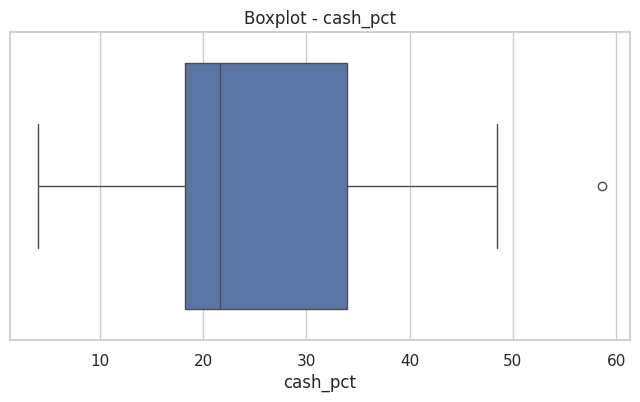

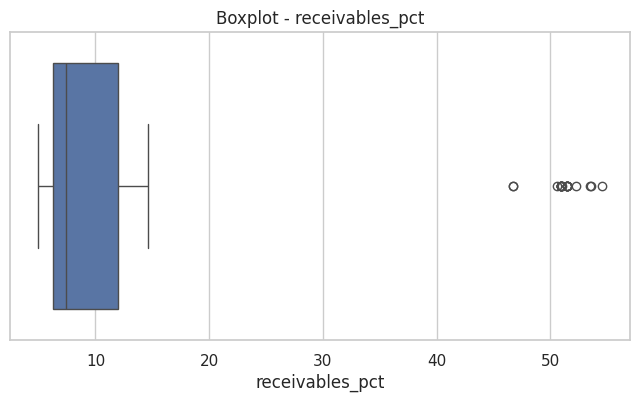

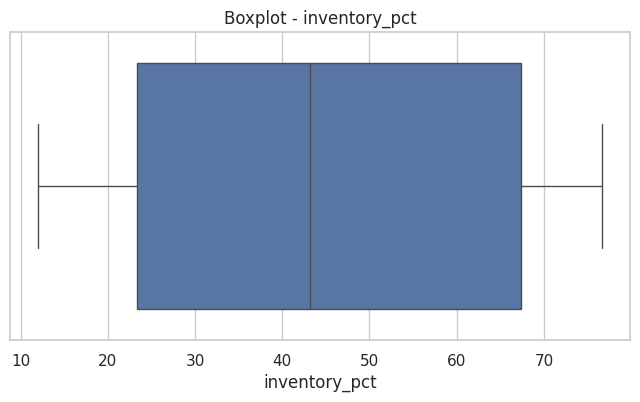

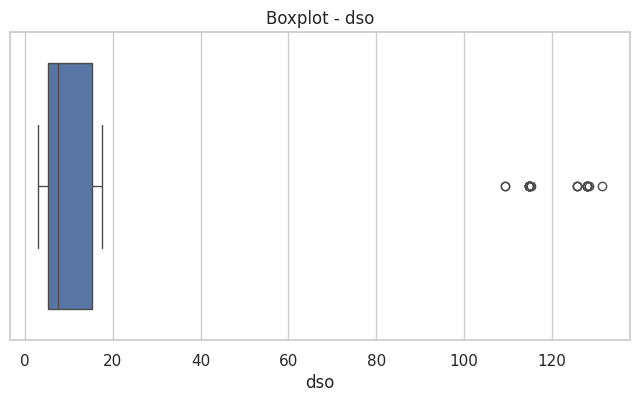

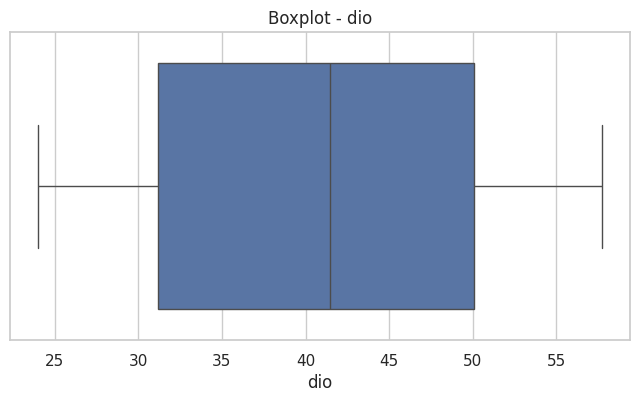

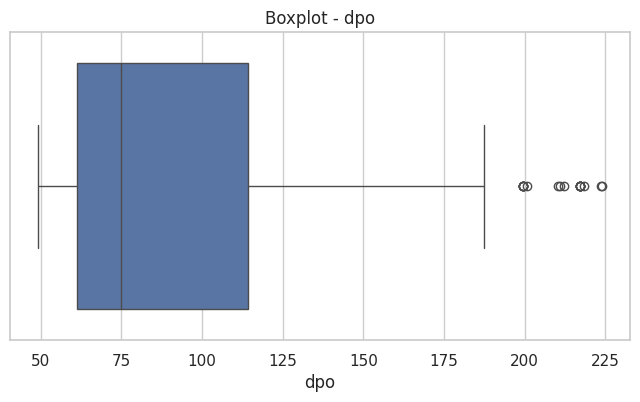

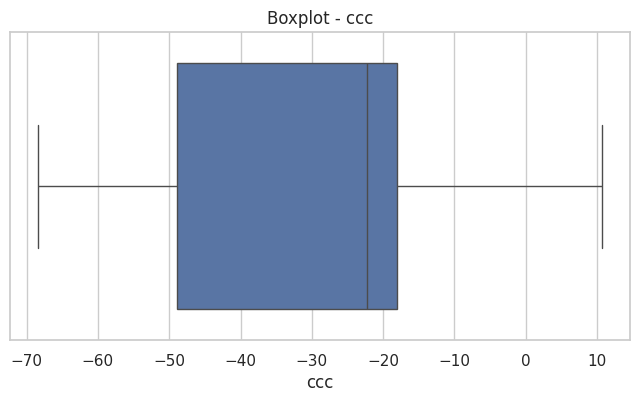

In [ ]:
# =========================================================
# INITIAL OUTLIER VISUALIZATION
# =========================================================

for col in features:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot - {col}')

    plt.show()

# Outlier Treatment using Winsorization

Financial datasets frequently contain extreme observations due to:
- industry differences,
- economic shocks,
- operational disruptions,
- and temporary liquidity events.

Since K-Means clustering relies on Euclidean distances, extreme values can disproportionately influence cluster formation.

To reduce this issue while preserving all observations, the analysis applies Winsorization.

Winsorization replaces extreme values beyond selected percentiles with the threshold percentile values themselves, reducing the impact of outliers without deleting data.

In [ ]:
# =========================================================
# WINSORIZATION
# =========================================================

# Create copy of dataset
X_winsorized = df[features].copy()

# Apply winsorization to each variable
for col in features:

    X_winsorized[col] = winsorize(
        X_winsorized[col],
        limits=[0.066, 0.66]
    )

print("Winsorization completed.")

Winsorization completed.


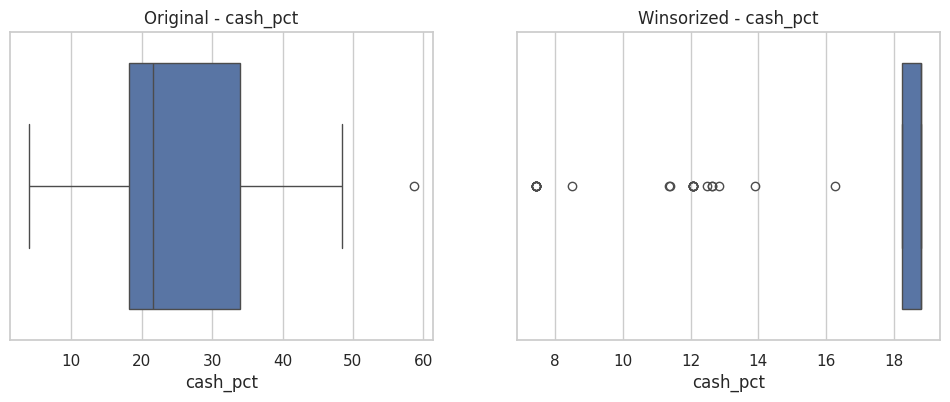

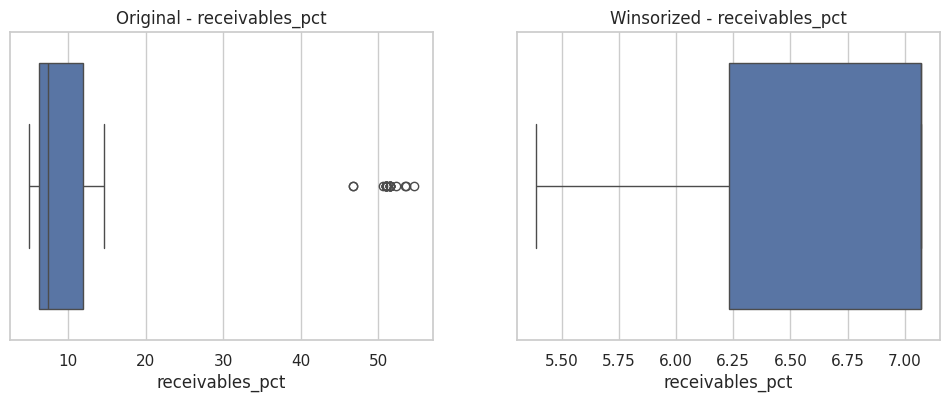

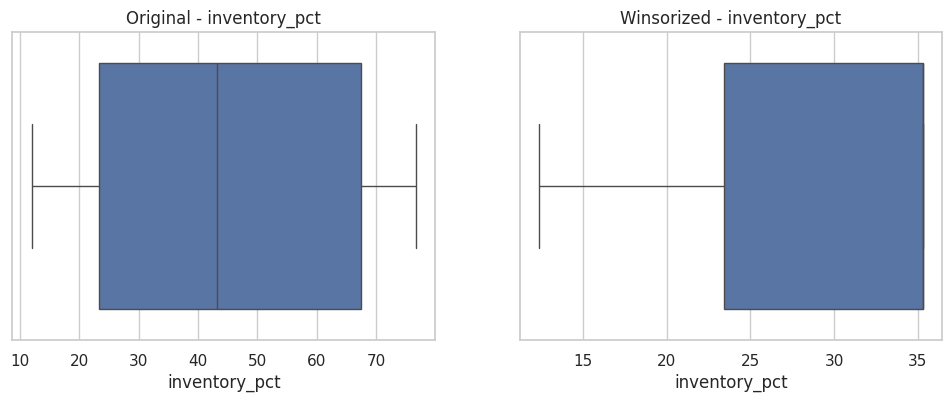

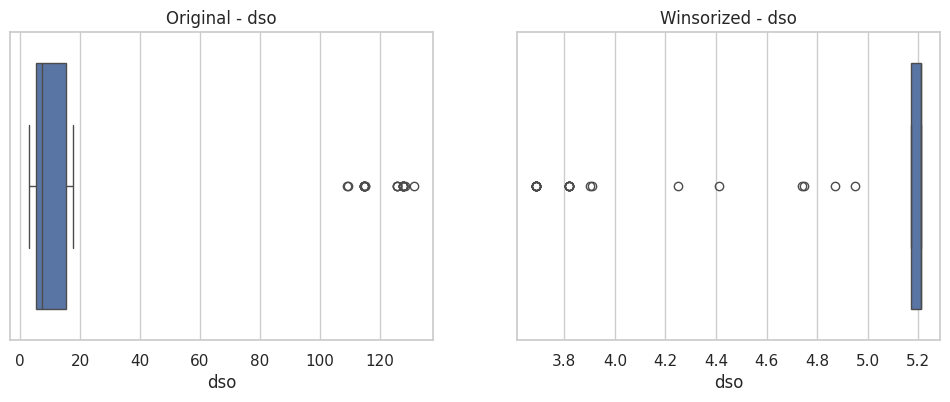

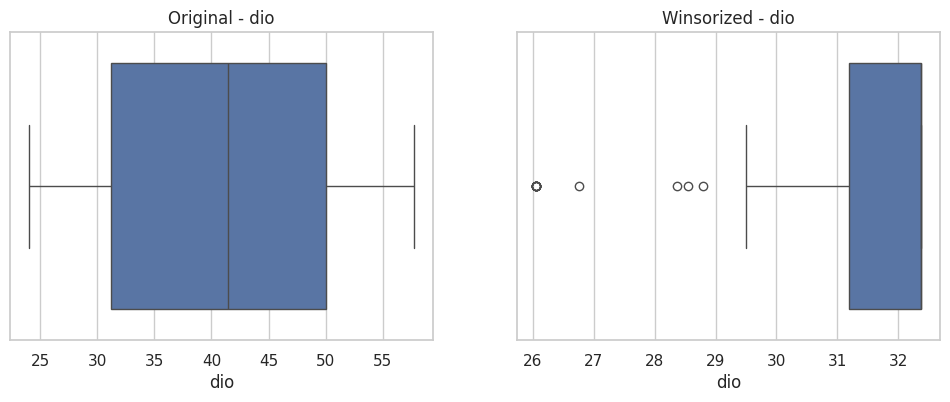

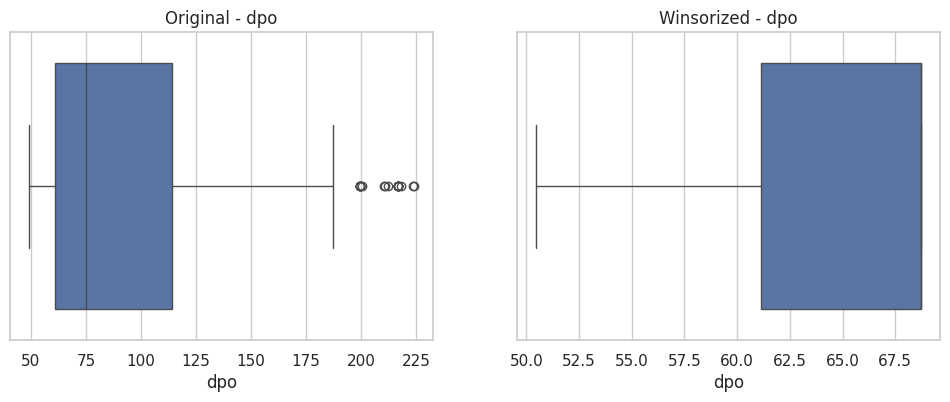

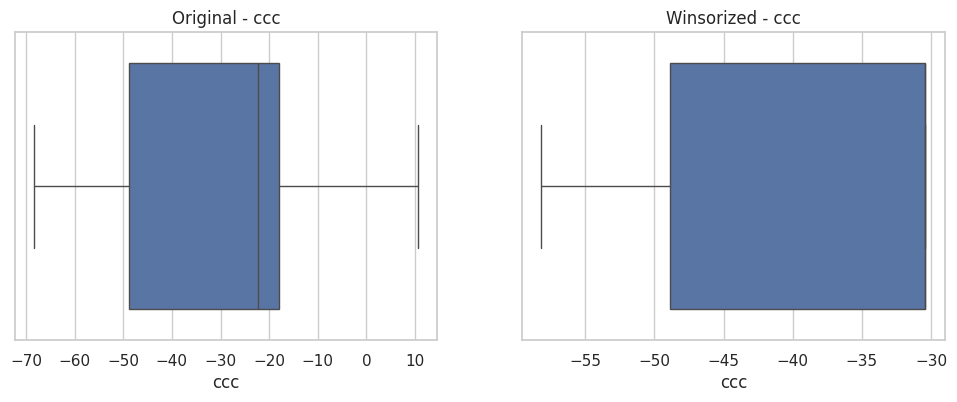

In [ ]:
# =========================================================
# BEFORE VS AFTER WINSORIZATION
# =========================================================

for col in features:

    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    # Original data
    sns.boxplot(x=df[col], ax=axes[0])
    axes[0].set_title(f'Original - {col}')

    # Winsorized data
    sns.boxplot(x=X_winsorized[col], ax=axes[1])
    axes[1].set_title(f'Winsorized - {col}')

    plt.show()

# Feature Scaling using RobustScaler

Clustering algorithms such as K-Means are distance-based models.

Variables with larger numerical scales can dominate Euclidean distance calculations and distort cluster formation.

To avoid this issue, variables must be normalized before clustering.

This analysis uses RobustScaler instead of StandardScaler because financial ratios often contain outliers.

RobustScaler uses:
- the median,
- and the interquartile range (IQR),

making it more robust to extreme observations.

In [ ]:
# =========================================================
# ROBUST SCALING
# =========================================================

scaler = RobustScaler()

X_scaled = scaler.fit_transform(X_winsorized)

# Convert back to DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=features
)

print("Scaling completed.")

X_scaled.head()

Scaling completed.


,cash_pct,receivables_pct,inventory_pct,dso,dio,dpo,ccc
0,-12.017857,0.0,0.0,0.0,-1.0,-2.009223,0.0
1,-12.017857,0.0,0.0,0.0,-1.0,-2.009223,0.0
2,-12.017857,0.0,0.0,0.0,-1.0,-2.009223,0.0
3,-12.017857,0.0,0.0,0.0,-1.0,-2.009223,0.0
4,-12.017857,0.0,0.0,0.0,-1.0,-2.009223,0.0


# Determining the Optimal Number of Clusters

One of the most important decisions in clustering analysis is selecting the appropriate number of clusters \(k\).

If the number of clusters is too small:
- different firm profiles may be grouped together,
- reducing interpretability.

If the number of clusters is too large:
- clusters become excessively fragmented,
- reducing generalizability.

To determine the optimal number of clusters, this project uses two complementary techniques:

1. Elbow Method
2. Silhouette Score

These methods help balance:
- cluster compactness,
- separation,
- and interpretability.

# Elbow Method

The Elbow Method evaluates how the within-cluster variation changes as the number of clusters increases.

K-Means minimizes:

\[
\text{WCSS} = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2
\]

where:
- \(C_i\) represents cluster \(i\),
- \(\mu_i\) is the centroid of cluster \(i\),
- and \(||x - \mu_i||^2\) is the squared Euclidean distance.

As \(k\) increases:
- within-cluster variation decreases,
- because clusters become more specialized.

The optimal \(k\) is typically identified at the "elbow point," where additional clusters provide diminishing improvements.

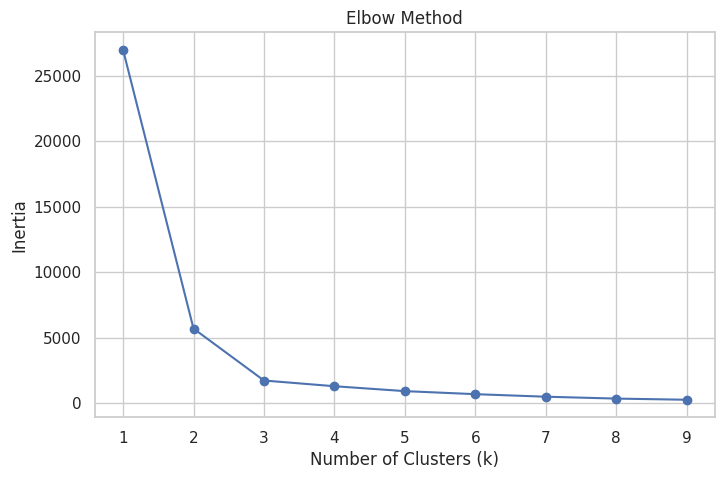

In [ ]:
# =========================================================
# ELBOW METHOD
# =========================================================

inertia = []

K_range = range(1, 10)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(8,5))

plt.plot(K_range, inertia, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

plt.show()

# Silhouette Score

The Silhouette Score measures how well-separated the clusters are.

The score compares:
- the average distance between an observation and other points in the same cluster,
- against the average distance to points in the nearest neighboring cluster.

The silhouette coefficient ranges from:

- -1 → poor clustering
- 0 → overlapping clusters
- +1 → highly separated clusters

Higher silhouette values indicate better cluster quality.

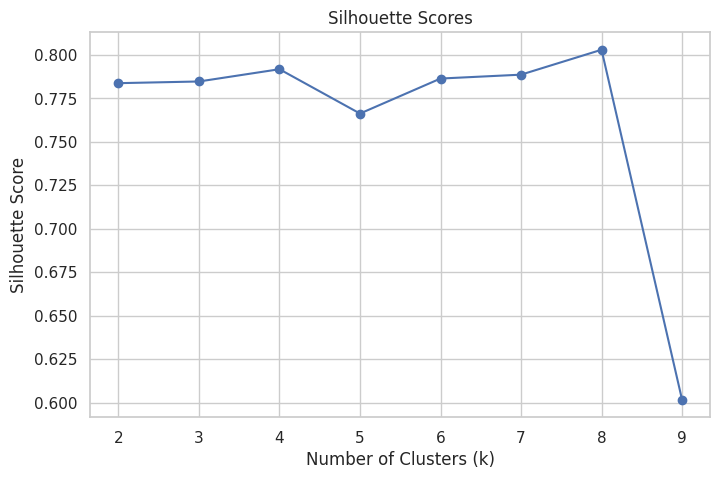

In [ ]:
# =========================================================
# SILHOUETTE SCORE
# =========================================================

silhouette_scores = []

K_range = range(2, 10)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, cluster_labels)

    silhouette_scores.append(score)

# Plot
plt.figure(figsize=(8,5))

plt.plot(K_range, silhouette_scores, marker='o')

plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

plt.show()

# Cluster Selection

The optimal number of clusters should balance:

- low within-cluster variation (Elbow Method),
- high cluster separation (Silhouette Score),
- and economic interpretability.

In financial clustering applications, interpretability is especially important because clusters should represent meaningful operational profiles.

Based on the Elbow Method and Silhouette Score, the selected number of clusters for this analysis is:

\[
k = X
\]

Replace \(X\) with the selected number after reviewing the plots.

# K-Means Clustering

After selecting the optimal number of clusters, the K-Means algorithm is applied to segment company-year observations according to their working capital management characteristics.

K-Means partitions the observations into \(k\) groups by minimizing within-cluster distances relative to the cluster centroids.

The resulting clusters represent different operational and liquidity management profiles across firms.

In [ ]:
# =========================================================
# FINAL K-MEANS MODEL
# =========================================================

optimal_k = 5

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

# Assign clusters
df['cluster'] = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed.")

# Show first observations
df[['ticker', 'ano', 'cluster']].head()

K-Means clustering completed.


,ticker,ano,cluster
0,WMT,2015,3
1,WMT,2016,3
2,WMT,2017,3
3,WMT,2018,3
4,WMT,2019,3


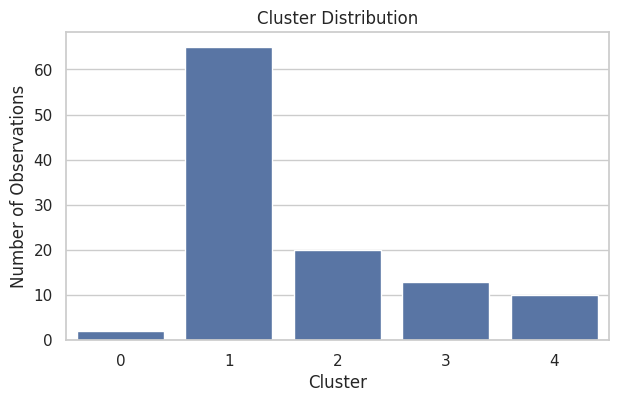

In [ ]:
# =========================================================
# CLUSTER DISTRIBUTION
# =========================================================

plt.figure(figsize=(7,4))

sns.countplot(
    x=df['cluster']
)

plt.title('Cluster Distribution')

plt.xlabel('Cluster')
plt.ylabel('Number of Observations')

plt.show()

# PCA Visualization

Because the dataset contains multiple dimensions, Principal Component Analysis (PCA) is used to reduce the feature space into two principal components for visualization purposes.

This allows us to visually inspect:
- cluster separation,
- overlap,
- and overall clustering structure.

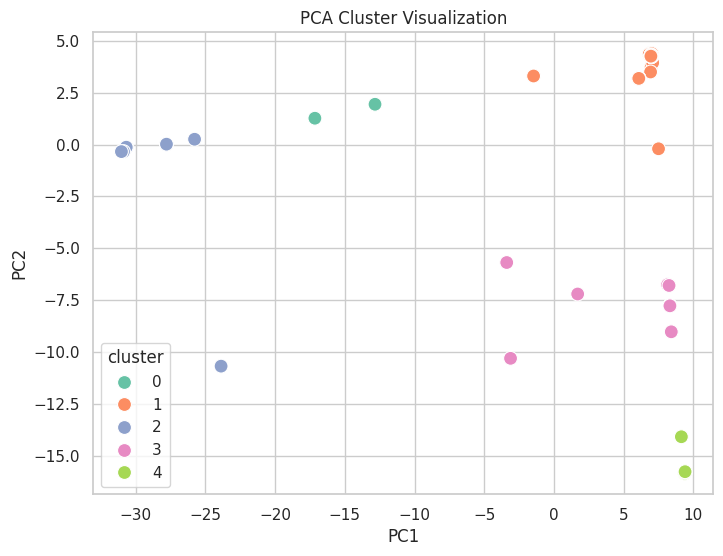

In [ ]:
# =========================================================
# PCA VISUALIZATION
# =========================================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Create dataframe
pca_df = pd.DataFrame({
    'PC1': X_pca[:,0],
    'PC2': X_pca[:,1],
    'cluster': df['cluster']
})

# Plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='Set2',
    s=100
)

plt.title('PCA Cluster Visualization')

plt.show()

# Hierarchical Clustering Validation

To complement the K-Means analysis, hierarchical clustering is also applied as a validation technique.

Unlike K-Means, hierarchical clustering does not require specifying the number of clusters beforehand.

Instead, it progressively groups observations according to their similarity structure, producing a dendrogram that visually represents cluster relationships.

This approach is useful for:
- validating cluster consistency,
- identifying natural groupings,
- and visually inspecting firm similarities.

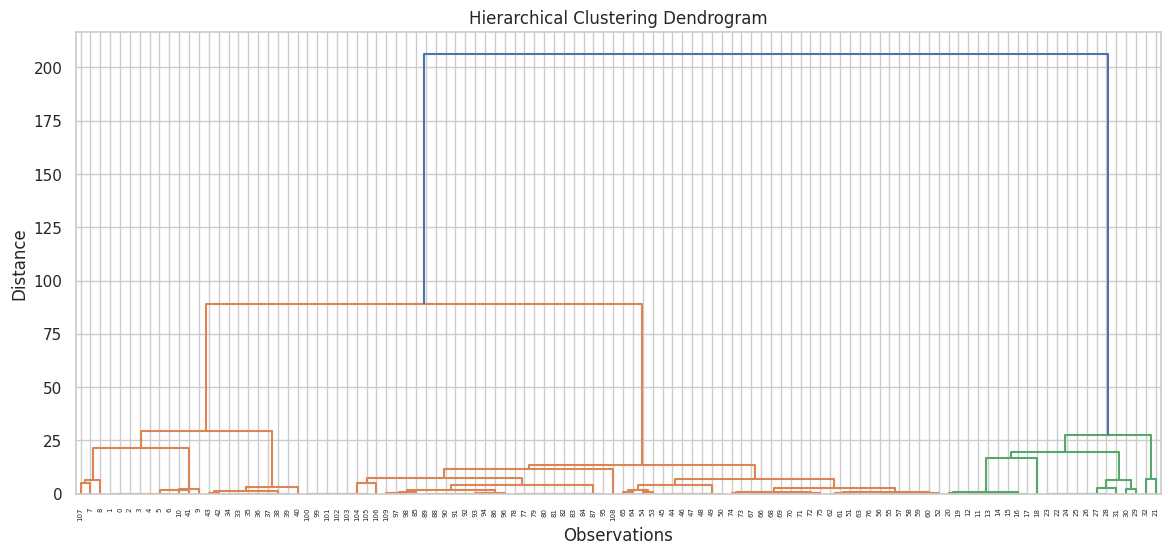

In [ ]:
# =========================================================
# HIERARCHICAL CLUSTERING
# =========================================================

# Generate linkage matrix
linked = linkage(
    X_scaled,
    method='ward'
)

# Plot dendrogram
plt.figure(figsize=(14,6))

dendrogram(
    linked,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True
)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Observations')
plt.ylabel('Distance')

plt.show()

# Cluster Profiling

After assigning clusters, the next step is interpreting the financial characteristics of each group.

Cluster profiling analyzes the average values of the working capital variables within each cluster.

This allows the identification of distinct operational profiles, such as:
- highly efficient firms,
- liquidity-heavy firms,
- inventory-intensive firms,
- or operationally constrained firms.

The objective is not only statistical segmentation, but also financial interpretation.

In [ ]:
# =========================================================
# CLUSTER CENTROIDS
# =========================================================

cluster_profile = df.groupby('cluster')[features].mean()

cluster_profile

,cash_pct,receivables_pct,inventory_pct,dso,dio,dpo,ccc
cluster,,,,,,,
0,32.165000,7.335000,54.350000,4.330000,33.440000,61.580000,-23.810000
1,29.501231,21.630615,28.577692,47.194154,41.750769,127.523077,-38.578154
2,27.361000,6.510000,59.510000,3.693500,34.668500,59.550000,-21.188000
3,12.250769,11.212308,69.293077,5.273846,33.270000,54.702308,-16.158462
4,6.992000,11.836000,74.464000,8.770000,55.177000,61.887000,2.060000


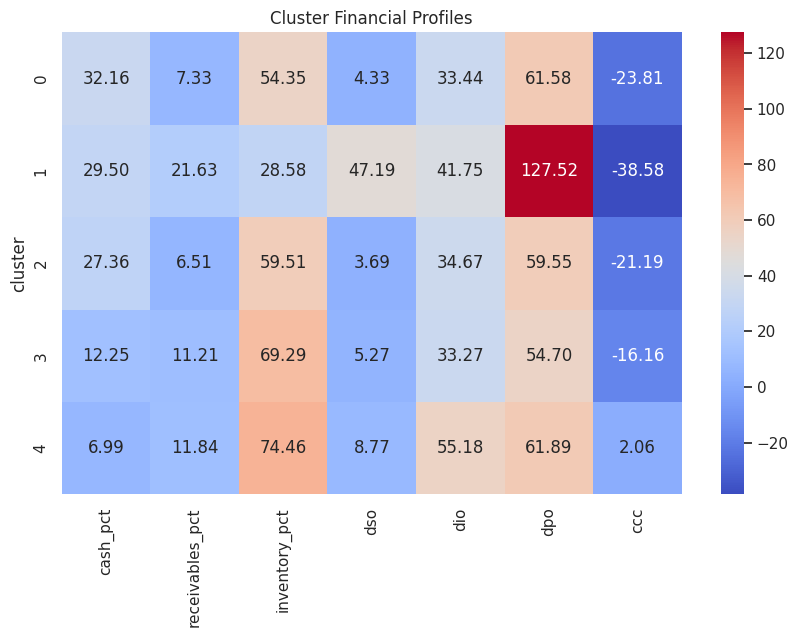

In [ ]:
# =========================================================
# CLUSTER PROFILE HEATMAP
# =========================================================

plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Cluster Financial Profiles')

plt.show()

# Interpreting Cluster Profiles

The heatmap allows comparison of average working capital behavior across clusters.

Key interpretations include:

- Lower DSO → faster customer collection
- Lower DIO → faster inventory turnover
- Higher DPO → longer supplier financing
- Lower CCC → more efficient cash conversion cycle

Clusters exhibiting:
- low DSO,
- low DIO,
- high DPO,
- and low CCC

can be interpreted as operationally efficient working capital managers.

# Identifying the Efficient Cluster

The efficient cluster is defined as the group with the strongest working capital efficiency profile.

Operational efficiency is associated with:
- lower DSO,
- lower DIO,
- lower CCC,
- and higher DPO.

To systematically identify the efficient cluster, an efficiency score is constructed using the cluster centroid values.

In [ ]:
# =========================================================
# EFFICIENCY SCORE
# =========================================================

cluster_profile['efficiency_score'] = (
    -cluster_profile['dso']
    -cluster_profile['dio']
    +cluster_profile['dpo']
    -cluster_profile['ccc']
)

cluster_profile

,cash_pct,receivables_pct,inventory_pct,dso,dio,dpo,ccc,efficiency_score
cluster,,,,,,,,
0,32.165000,7.335000,54.350000,4.330000,33.440000,61.580000,-23.810000,47.620000
1,29.501231,21.630615,28.577692,47.194154,41.750769,127.523077,-38.578154,77.156308
2,27.361000,6.510000,59.510000,3.693500,34.668500,59.550000,-21.188000,42.376000
3,12.250769,11.212308,69.293077,5.273846,33.270000,54.702308,-16.158462,32.316923
4,6.992000,11.836000,74.464000,8.770000,55.177000,61.887000,2.060000,-4.120000


In [ ]:
# =========================================================
# IDENTIFY EFFICIENT CLUSTER
# =========================================================

efficient_cluster = cluster_profile['efficiency_score'].idxmax()

print(f"Efficient Cluster: {efficient_cluster}")

Efficient Cluster: 1


# Distance-Based Inefficiency Score

To quantify operational inefficiency, the analysis calculates the Euclidean distance between each observation and the centroid of the efficient cluster.

Observations closer to the efficient cluster exhibit:
- stronger working capital management,
- faster operational cash conversion,
- and more optimized liquidity structures.

Larger distances indicate increasing deviation from the operational benchmark.

This distance metric becomes the project's final inefficiency score.

In [ ]:
# =========================================================
# EFFICIENT CLUSTER CENTROID
# =========================================================

efficient_centroid = kmeans.cluster_centers_[efficient_cluster]

In [ ]:
# =========================================================
# EUCLIDEAN DISTANCE TO EFFICIENT CLUSTER
# =========================================================

distances = np.linalg.norm(
    X_scaled - efficient_centroid,
    axis=1
)

# Add score to dataframe
df['inefficiency_score'] = distances

df.head()

,ticker,sector,ano,cash_pct,receivables_pct,inventory_pct,dso,dio,dpo,ccc,cluster,inefficiency_score
0,WMT,Retail Tradicional,2015,12.07,11.95,71.56,5.21,31.19,53.46,-17.06,3,12.054035
1,WMT,Retail Tradicional,2016,12.07,11.95,71.56,5.21,31.19,53.46,-17.06,3,12.054035
2,WMT,Retail Tradicional,2017,12.07,11.95,71.56,5.21,31.19,53.46,-17.06,3,12.054035
3,WMT,Retail Tradicional,2018,12.07,11.95,71.56,5.21,31.19,53.46,-17.06,3,12.054035
4,WMT,Retail Tradicional,2019,12.07,11.95,71.56,5.21,31.19,53.46,-17.06,3,12.054035


In [ ]:
# =========================================================
# MOST EFFICIENT OBSERVATIONS
# =========================================================

df_sorted = df.sort_values(
    by='inefficiency_score'
)

df_sorted[
    [
        'ticker',
        'sector',
        'ano',
        'cluster',
        'inefficiency_score'
    ]
].head(15)

,ticker,sector,ano,cluster,inefficiency_score
74,TSLA,Automotriz,2023,1,0.699921
68,TSLA,Automotriz,2017,1,0.808398
71,TSLA,Automotriz,2020,1,0.808398
72,TSLA,Automotriz,2021,1,0.808398
66,TSLA,Automotriz,2015,1,0.808398
69,TSLA,Automotriz,2018,1,0.808398
67,TSLA,Automotriz,2016,1,0.808398
70,TSLA,Automotriz,2019,1,0.808398
75,TSLA,Automotriz,2024,1,0.846288
73,TSLA,Automotriz,2022,1,0.907062


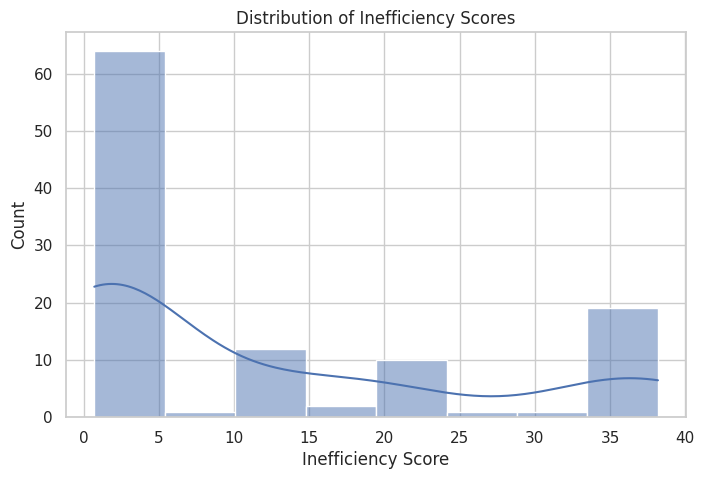

In [ ]:
# =========================================================
# INEFFICIENCY SCORE DISTRIBUTION
# =========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['inefficiency_score'],
    kde=True
)

plt.title('Distribution of Inefficiency Scores')

plt.xlabel('Inefficiency Score')

plt.show()

# Conclusion

The clustering analysis successfully identified distinct working capital management profiles across firms and industries.

Rather than relying exclusively on traditional industry classifications, the model grouped firms according to operational and liquidity management behavior.

The results demonstrate that firms from different sectors may still exhibit highly similar working capital structures and operational dynamics.

Additionally, the distance-based inefficiency score provides a quantitative measure of deviation from the operational benchmark cluster, creating a scalable metric for future predictive or econometric analysis.